# Hybrid Strategy — Technical Scoring + 10-Stock Portfolio (GPW 2000–2025)

Combination of two approaches:
- **Scoring:** technical indicators (RSI, MACD, Stochastic, CCI, ROC, EMA) as in rotation strategies
- **Portfolio:** up to 10 stocks simultaneously, wide entry/exit thresholds as in momentum strategies

**Three stop-loss variants:** −10%, −20%, −30% from purchase price.

**Data:** `open_prices.csv` (GPW, ~354 stocks, 2000–2025) — no external dependencies.


---
## Algorithm Description

### 1. Technical Scoring (Daily)

For each stock we compute a score [0–1] from 7 indicators:

| Indicator | Weight |
|----------|------|
| RSI(14) | 20% |
| MACD histogram | 20% |
| Stochastic %K(14) | 10% |
| CCI(20) | 10% |
| ROC(10) | 20% |
| EMA20 > EMA50 | 10% |
| EMA50 trend | 10% |

### 2. Portfolio Logic (10 Stocks)

The ranking is computed on each day's close; the resulting buys/sells execute at the **next** session's price (no lookahead bias). The stop-loss is the one exception — it triggers on the current session's price, since that is the price crossing the threshold.

Each session:
1. **Sell** a position if: decline from purchase price > stop-loss threshold
2. **Fill** the portfolio to 10 stocks — buy the highest-scored stocks not already held
3. **Allocation** for new position = `available_cash / number_of_open_slots`
4. **Top-up** — remaining cash goes to the most underfunded position

### 3. Variants

| | Stop −10% | Stop −20% | Stop −30% |
|---|---|---|---|
| Stop-loss from purchase price | −10% | −20% | −30% |
| Portfolio | 10 stocks | 10 stocks | 10 stocks |
| Rebalancing | Only on ranking change | Only on ranking change | Only on ranking change |
| Tax | Not included | Not included | Not included |

### 4. Model Limitations
- No transaction costs or Belka capital gains tax
- Signal computed on close of day *t*, trades executed at day *t+1* prices — no look-ahead bias (stop-loss uses the current session's price by design)
- Survivorship bias: data may not include companies delisted from GPW
- Indicators require ~50 days of warmup — first positions opened after this period

---
*Analysis and code: Python. Not investment advice.*


## 0. Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

OUT = Path('charts_hybrid')
OUT.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 200,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.titlesize': 13, 'axes.labelsize': 11,
})

COLORS = {
    's1': '#E74C3C', 's2': '#3498DB', 's3': '#2ECC71',
    'buy': '#27AE60', 'sell': '#E74C3C', 'neutral': '#95A5A6'
}
print('Setup OK —', OUT.resolve())


Setup OK — D:\MOJE\PROJEKTY\stock-technical-analysis\hybrid-strategy\charts_hybrid


## 1. Load Data

In [2]:
df_raw = pd.read_csv('open_prices.csv', index_col='Date', parse_dates=True)
df_raw = df_raw.sort_index()
# Keep only stocks with sufficient history for indicators
df_raw = df_raw.loc[:, df_raw.notna().sum() >= 100]

print(f'Zakres:        {df_raw.index[0].date()} – {df_raw.index[-1].date()}')
print(f'Liczba dni:    {len(df_raw)}')
print(f'Liczba spółek: {df_raw.shape[1]}')


Zakres:        2000-01-03 – 2025-09-18
Liczba dni:    6670
Liczba spółek: 350


## 2. Technical Indicators and Scoring

In [3]:
# ── Indicators (no external libraries) ───────────────────────────────────
def rsi(close, w=14):
    d = close.diff()
    g = d.clip(lower=0).rolling(w).mean()
    l = (-d.clip(upper=0)).rolling(w).mean()
    return 100 - 100 / (1 + g / l.replace(0, np.nan))

def macd_hist(close, fast=12, slow=26, sig=9):
    m = close.ewm(span=fast, adjust=False).mean() - close.ewm(span=slow, adjust=False).mean()
    return m - m.ewm(span=sig, adjust=False).mean()

def stoch(close, w=14):
    lo, hi = close.rolling(w).min(), close.rolling(w).max()
    return (close - lo) / (hi - lo).replace(0, np.nan) * 100

def cci(close, w=20):
    sma = close.rolling(w).mean()
    mad = close.rolling(w).apply(lambda x: np.mean(np.abs(x - x.mean())), raw=True)
    return (close - sma) / (0.015 * mad.replace(0, np.nan))

def roc(close, w=10):
    return (close / close.shift(w) - 1) * 100

def norm_clip(s, lo, hi):
    return ((s - lo) / (hi - lo)).clip(0, 1)

def build_scores(df):
    """Score kompozytowy [0–1] dla każdej spółki i każdego dnia."""
    r   = rsi(df)
    m   = macd_hist(df)
    st  = stoch(df)
    c   = cci(df)
    ro  = roc(df)
    e20 = df.ewm(span=20, adjust=False).mean()
    e50 = df.ewm(span=50, adjust=False).mean()

    # normalize to [0,1]
    q05 = lambda x: x.stack().quantile(0.05)
    q95 = lambda x: x.stack().quantile(0.95)

    return (
        0.20 * norm_clip(r,   0,    100) +
        0.20 * norm_clip(m,   q05(m), q95(m)) +
        0.10 * norm_clip(st,  0,    100) +
        0.10 * norm_clip(c,  -200,  200) +
        0.20 * norm_clip(ro,  q05(ro), q95(ro)) +
        0.10 * (e20 > e50).astype(float) +
        0.10 * norm_clip(e20 / e50.replace(0, np.nan) - 1, -0.1, 0.1)
    )

print('Computing scores for all stocks and days (may take a moment)...')
score_df = build_scores(df_raw)
print(f'Scores ready: {score_df.shape}')


Computing scores for all stocks and days (may take a moment)...


Scores ready: (6670, 350)


## 3. Backtest Engine — 10-Stock Portfolio

In [4]:
def run_hybrid_backtest(df_prices, score_df, stop_loss,
                        max_size=10, start_capital=10_000):
    """
    Portfel do max_size spółek.
    Sprzedaje gdy spadek od ceny zakupu > stop_loss.
    Kupuje najlepiej scorowane na wolne miejsca.

    Brak lookahead bias: ranking liczony jest na zamknięciu dnia
    `signal_date`, a transakcje wykonywane są po cenach następnej
    sesji (`trade_date`). Wyjątek: stop-loss reaguje na cenę bieżącej
    sesji (`trade_date`), bo to ona przekracza próg.
    """
    cash      = start_capital
    positions = {}   # ticker -> {shares, avg_cost}
    trades    = []
    equity    = []

    def cur_price(prices, ticker):
        """Cena z bieżącej sesji; np.nan jeśli brak notowania (klucz może istnieć z NaN)."""
        p = prices.get(ticker, np.nan)
        return p if (p is not None and not np.isnan(p)) else np.nan

    def value_at(prices, ticker):
        """Wycena pozycji: bieżąca cena, a gdy brak notowania — ostatni znany koszt (avg_cost)."""
        p = cur_price(prices, ticker)
        return p if not np.isnan(p) else positions[ticker]['avg_cost']

    common = df_prices.index.intersection(score_df.index)
    dates  = list(common)

    # iterujemy parami: ranking z `signal_date`, egzekucja po cenach `trade_date`
    for signal_date, trade_date in zip(dates[:-1], dates[1:]):
        prices = df_prices.loc[trade_date]          # ceny egzekucji (następna sesja)
        scores = score_df.loc[signal_date].dropna() # ranking znany na zamknięciu poprz. sesji

        # ── SELL: stop-loss (na cenie bieżącej sesji) ─────────────────────────
        for ticker in list(positions):
            price = cur_price(prices, ticker)
            if np.isnan(price):
                continue
            drop = (price - positions[ticker]['avg_cost']) / positions[ticker]['avg_cost']
            if drop <= -stop_loss:
                proceeds = positions[ticker]['shares'] * price
                cash += proceeds
                trades.append(dict(date=trade_date, action='SELL', ticker=ticker,
                                   price=price, shares=positions[ticker]['shares'],
                                   value=proceeds))
                del positions[ticker]

        # ── BUY: fill up to max_size ──────────────────────────────────────────
        slots = max_size - len(positions)
        if slots > 0 and cash > 0:
            # candidates: not in portfolio, price available on the execution day
            held = set(positions.keys())
            valid_tickers = scores.index[
                scores.index.isin(prices.dropna().index) &
                ~scores.index.isin(held)
            ]
            candidates = scores.loc[valid_tickers].sort_values(ascending=False)
            top = candidates.index[:slots]

            per_slot = cash / slots
            for ticker in top:
                price = cur_price(prices, ticker)
                if np.isnan(price) or price <= 0:
                    continue
                alloc  = min(per_slot, cash)
                shares = int(np.floor(alloc / price))
                if shares <= 0:
                    continue
                cost = shares * price
                cash -= cost
                positions[ticker] = {'shares': shares, 'avg_cost': price}
                trades.append(dict(date=trade_date, action='BUY', ticker=ticker,
                                   price=price, shares=shares, value=cost))

        # ── TOP-UP: remaining cash to most underfunded position ────────────────
        if positions and cash > 1:
            mv = {t: positions[t]['shares'] * value_at(prices, t) for t in positions}
            worst = min(mv, key=mv.get)
            price = cur_price(prices, worst)
            if not np.isnan(price) and price > 0:
                shares = int(np.floor(cash / price))
                if shares > 0:
                    cost = shares * price
                    cash -= cost
                    p = positions[worst]
                    p['avg_cost'] = (p['shares']*p['avg_cost'] + cost) / (p['shares'] + shares)
                    p['shares'] += shares
                    trades.append(dict(date=trade_date, action='BUY', ticker=worst,
                                       price=price, shares=shares, value=cost))

        # ── EQUITY SNAPSHOT ────────────────────────────────────────────────────
        # Wycena pozycji bez notowania w danym dniu używa avg_cost (a nie NaN),
        # więc krzywa kapitału nie psuje się przez luki w danych.
        port_val = sum(positions[t]['shares'] * value_at(prices, t) for t in positions)
        equity.append(dict(date=trade_date, capital=cash + port_val,
                           cash=cash, n_positions=len(positions)))

    cap_df    = pd.DataFrame(equity).set_index('date')
    cap_df.index = pd.to_datetime(cap_df.index)
    trades_df = pd.DataFrame(trades)
    return cap_df, trades_df

print('Engine ready.')

Engine ready.


## 4. Run — Three Stop-Loss Thresholds

In [5]:
STOP_LEVELS = {
    'Stop −10%': 0.10,
    'Stop −20%': 0.20,
    'Stop −30%': 0.30,
}
COLORS_LIST = [COLORS['s1'], COLORS['s2'], COLORS['s3']]

results = {}
for name, sl in STOP_LEVELS.items():
    print(f'Backtesting {name}...')
    cap, trades = run_hybrid_backtest(df_raw, score_df, stop_loss=sl)
    results[name] = dict(cap=cap, trades=trades, stop=sl)
    final = cap['capital'].iloc[-1]
    ret   = (final / 10_000 - 1) * 100
    ntxn  = len(trades[trades['action']=='BUY']) if not trades.empty else 0
    print(f'  Kapitał: {final:>12,.0f} PLN  |  Zwrot: {ret:>+8.1f}%  |  Transakcji BUY: {ntxn}')


Backtesting Stop −10%...


  Kapitał:      487,536 PLN  |  Zwrot:  +4775.4%  |  Transakcji BUY: 113
Backtesting Stop −20%...


  Kapitał:      241,320 PLN  |  Zwrot:  +2313.2%  |  Transakcji BUY: 125
Backtesting Stop −30%...


  Kapitał:      169,984 PLN  |  Zwrot:  +1599.8%  |  Transakcji BUY: 60


## 5. Visualizations

> Saved to `charts_hybrid/`

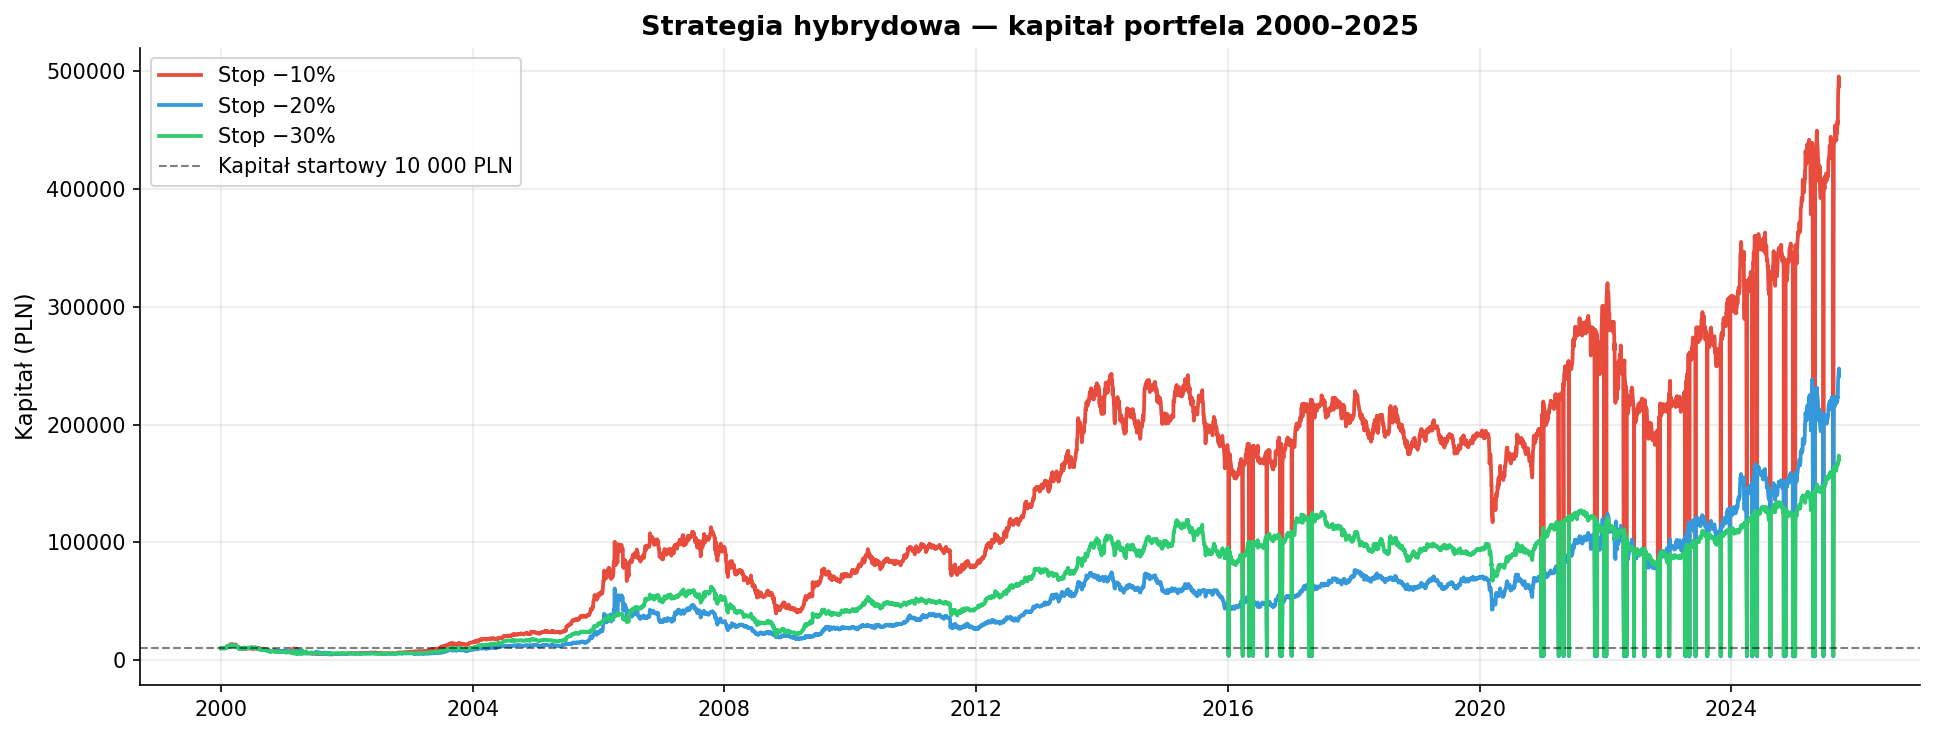

Saved: h01_kapital_porownanie.png


In [6]:
# ── Fig 1: Capital — variant comparison ────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
for (name, res), col in zip(results.items(), COLORS_LIST):
    ax.plot(res['cap'].index, res['cap']['capital'],
            label=name, color=col, linewidth=1.8)
ax.axhline(10_000, color='black', linestyle='--', linewidth=1,
           alpha=0.5, label='Kapitał startowy 10 000 PLN')
ax.set_title('Strategia hybrydowa — kapitał portfela 2000–2025', fontweight='bold')
ax.set_ylabel('Kapitał (PLN)')
ax.legend()
plt.tight_layout()
fig.savefig(OUT / 'h01_kapital_porownanie.png', bbox_inches='tight')
plt.show()
print('Saved: h01_kapital_porownanie.png')


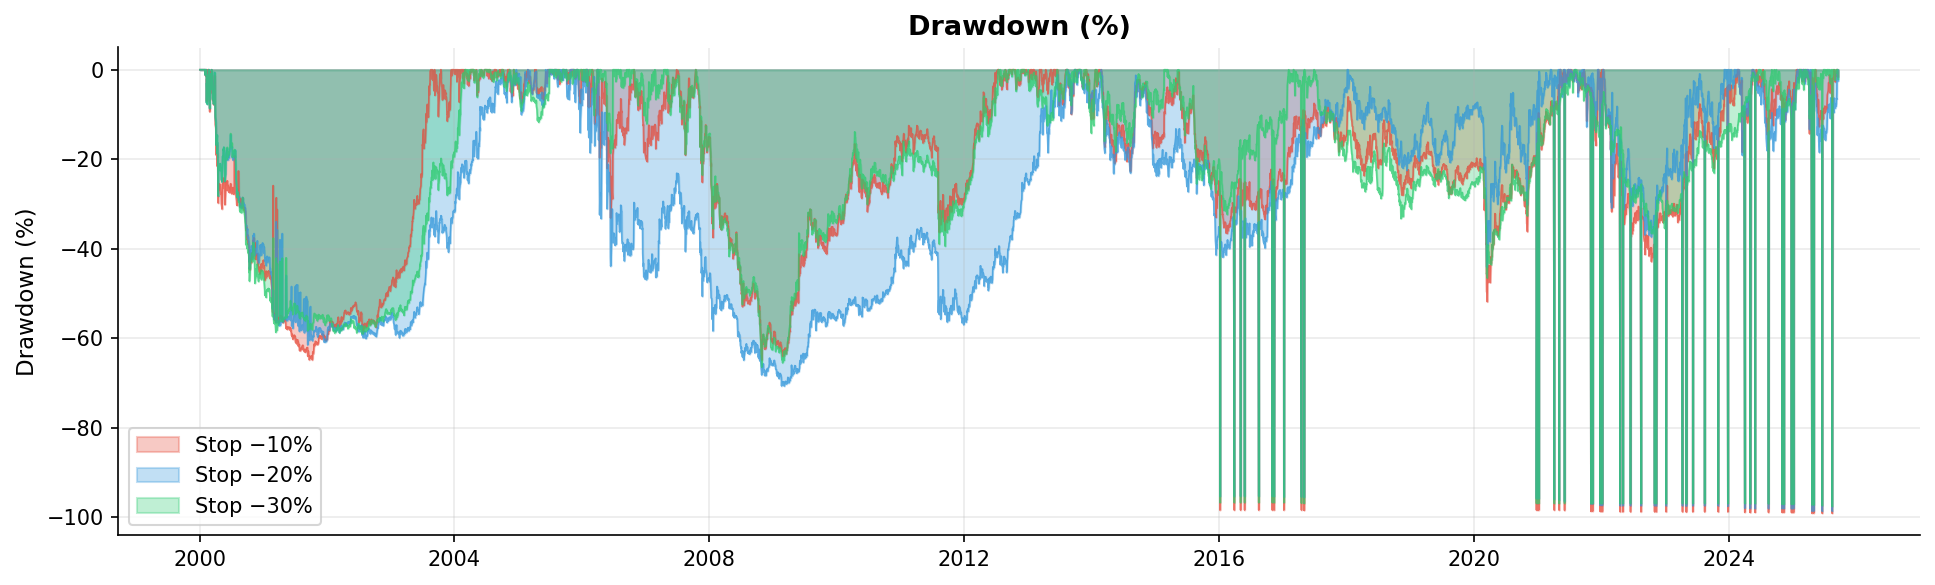

Saved: h02_drawdown.png


In [7]:
# ── Fig 2: Drawdown ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
for (name, res), col in zip(results.items(), COLORS_LIST):
    cap = res['cap']['capital']
    dd  = (cap - cap.cummax()) / cap.cummax() * 100
    ax.fill_between(dd.index, dd, 0, alpha=0.3, color=col, label=name)
    ax.plot(dd.index, dd, color=col, linewidth=0.8, alpha=0.7)
ax.set_title('Drawdown (%)', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend()
plt.tight_layout()
fig.savefig(OUT / 'h02_drawdown.png', bbox_inches='tight')
plt.show()
print('Saved: h02_drawdown.png')


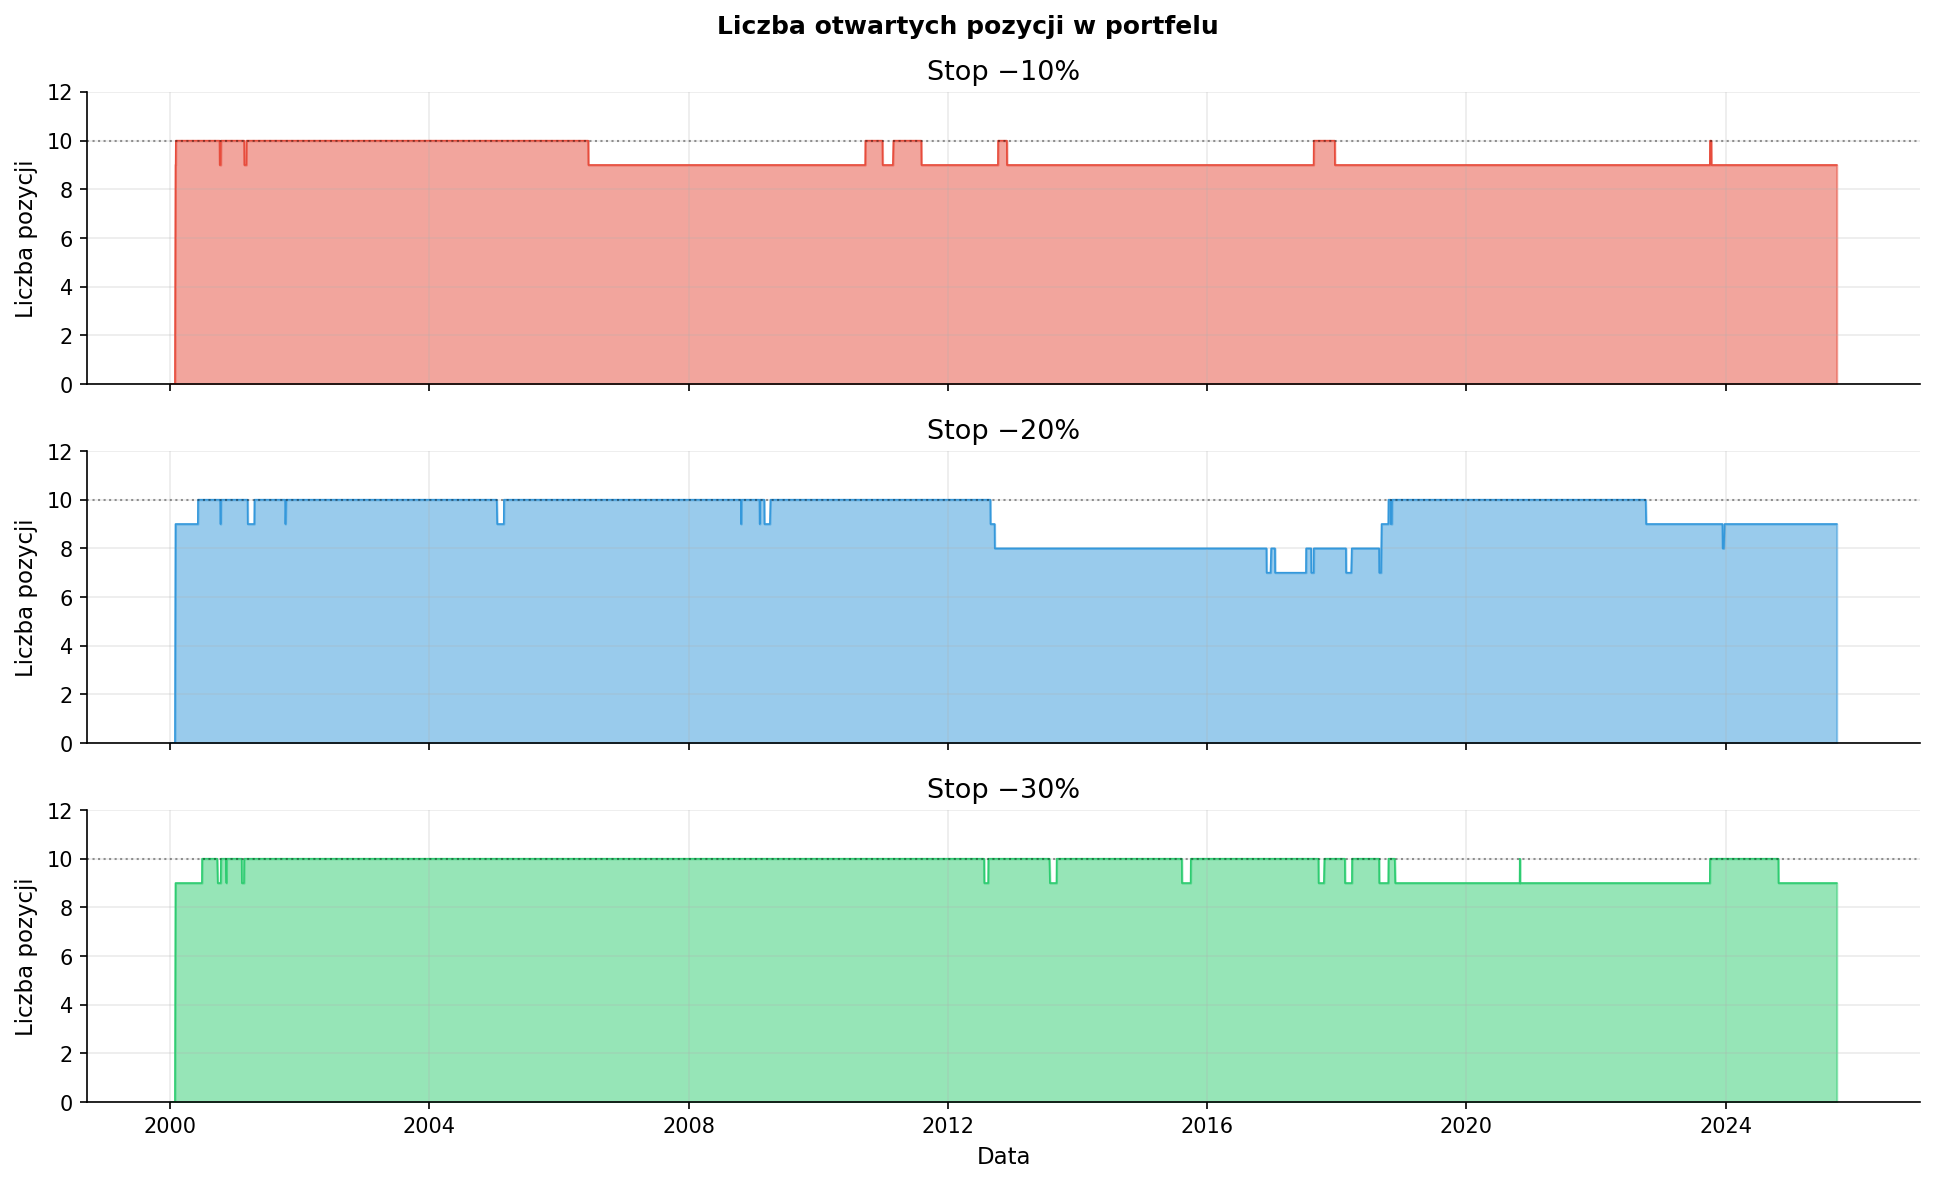

Saved: h03_liczba_pozycji.png


In [8]:
# ── Fig 3: Liczba pozycji w portfelu ────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, (name, res), col in zip(axes, results.items(), COLORS_LIST):
    ax.fill_between(res['cap'].index, res['cap']['n_positions'],
                    alpha=0.5, color=col)
    ax.plot(res['cap'].index, res['cap']['n_positions'], color=col, linewidth=0.8)
    ax.axhline(10, color='black', linestyle=':', alpha=0.4, linewidth=1)
    ax.set_ylabel('Liczba pozycji')
    ax.set_ylim(0, 12)
    ax.set_title(name)
axes[-1].set_xlabel('Data')
fig.suptitle('Liczba otwartych pozycji w portfelu', fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'h03_liczba_pozycji.png', bbox_inches='tight')
plt.show()
print('Saved: h03_liczba_pozycji.png')


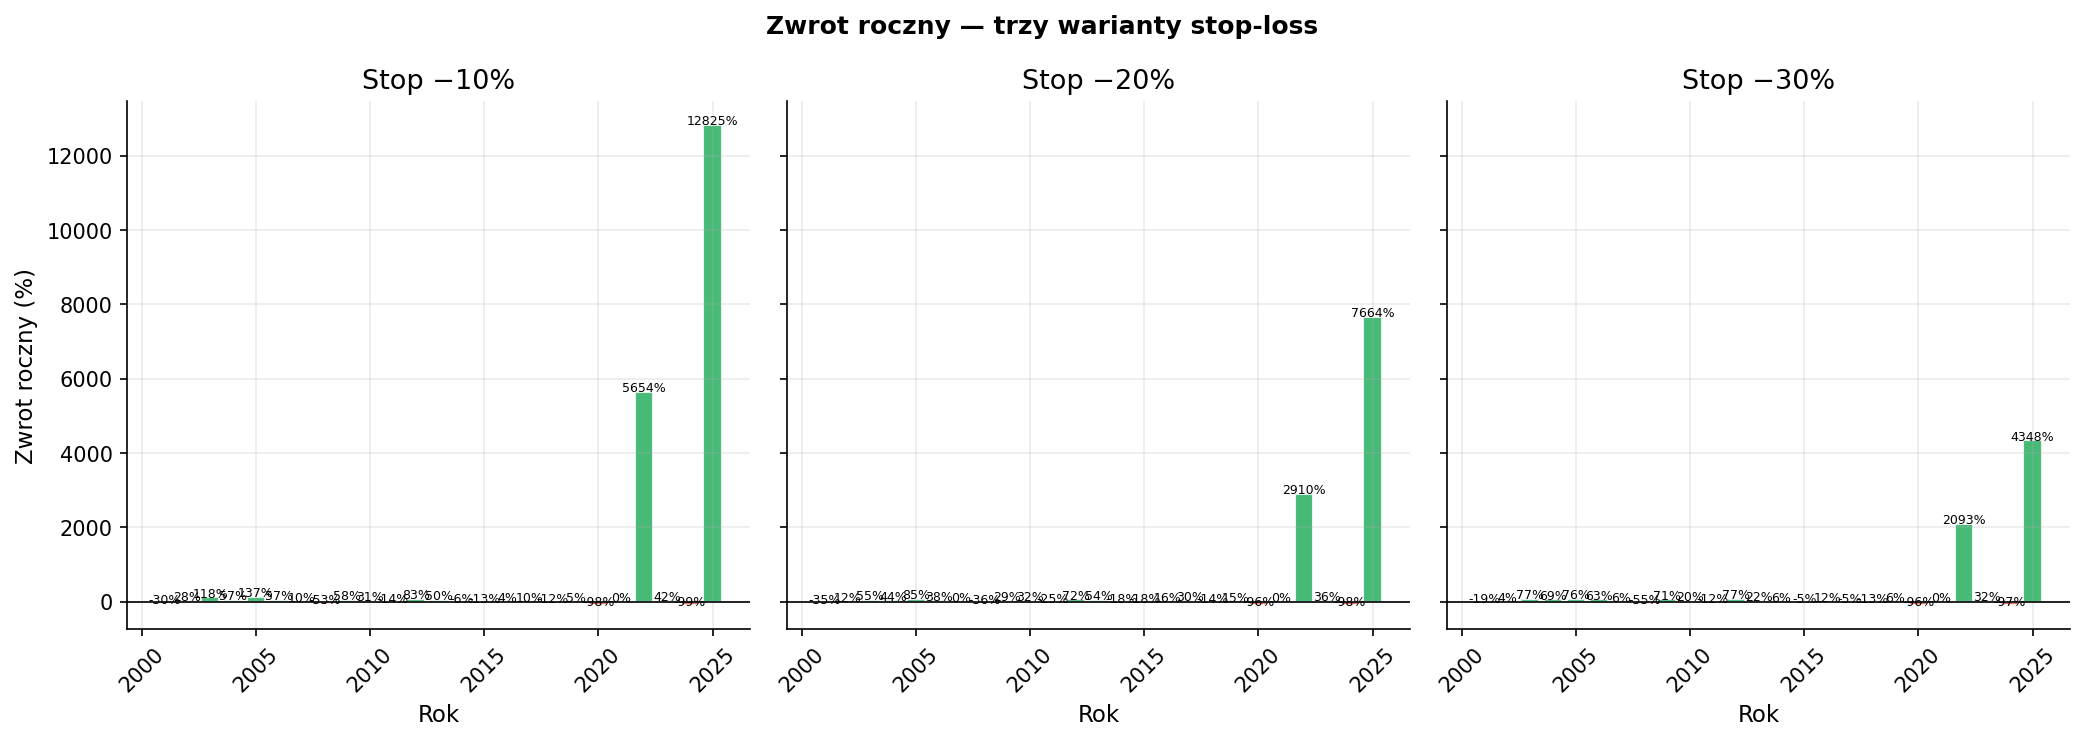

Saved: h04_zwrot_roczny.png


In [9]:
# ── Fig 4: Zwrot roczny — wszystkie warianty ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for ax, (name, res), col in zip(axes, results.items(), COLORS_LIST):
    cap    = res['cap']['capital']
    annual = cap.resample('Y').last().pct_change().dropna() * 100
    annual.index = annual.index.year
    bar_colors = [COLORS['buy'] if v >= 0 else COLORS['sell'] for v in annual]
    bars = ax.bar(annual.index, annual.values, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(name)
    ax.set_xlabel('Rok')
    ax.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, annual.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + (1 if val >= 0 else -4),
                f'{val:.0f}%', ha='center', fontsize=6)
axes[0].set_ylabel('Zwrot roczny (%)')
fig.suptitle('Zwrot roczny — trzy warianty stop-loss', fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'h04_zwrot_roczny.png', bbox_inches='tight')
plt.show()
print('Saved: h04_zwrot_roczny.png')


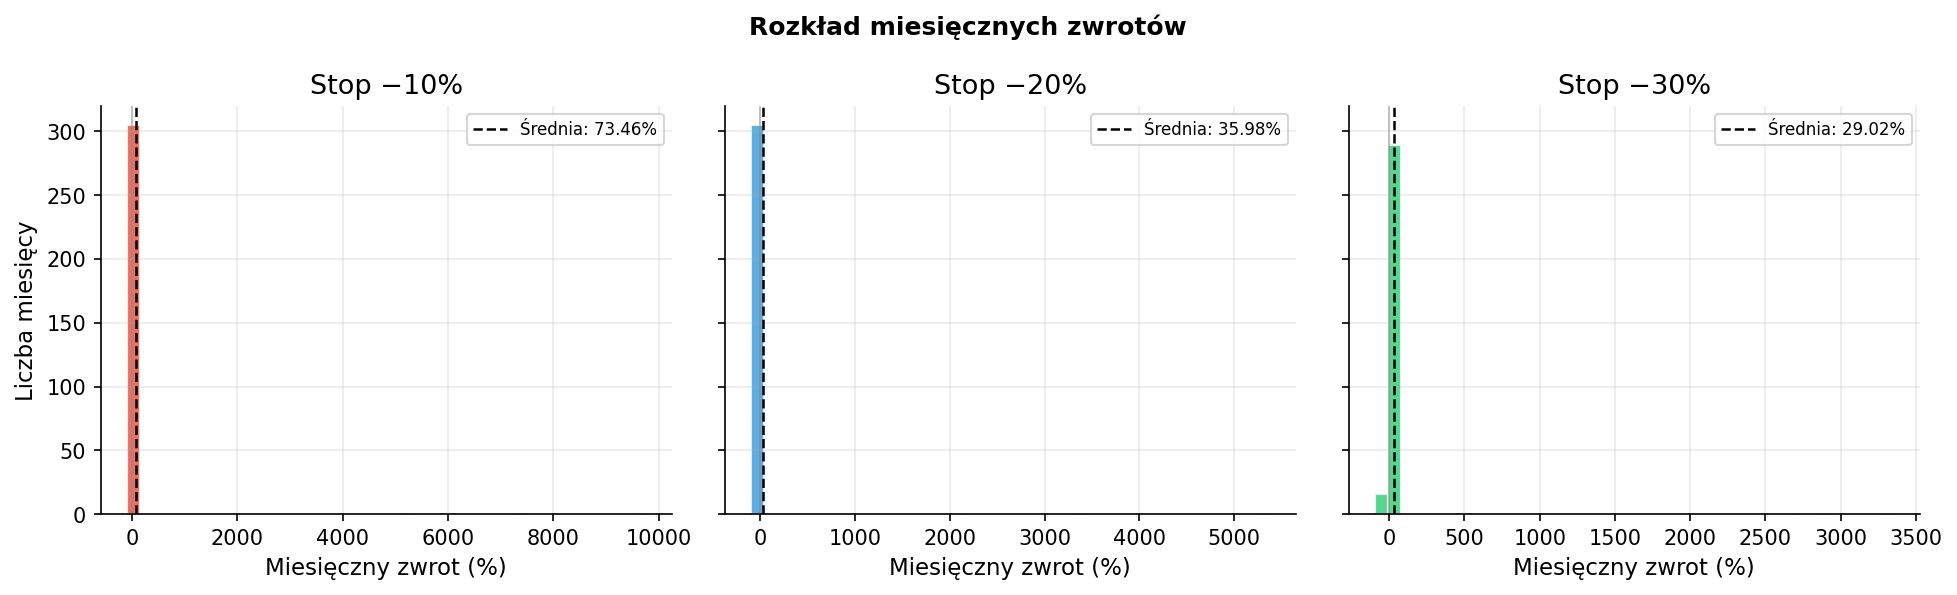

Saved: h05_rozklad_zwrotow.png


In [10]:
# ── Fig 5: Distribution of monthly portfolio returns ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, (name, res), col in zip(axes, results.items(), COLORS_LIST):
    m_ret = res['cap']['capital'].resample('M').last().pct_change().dropna() * 100
    ax.hist(m_ret, bins=40, color=col, alpha=0.8, edgecolor='white')
    ax.axvline(m_ret.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Średnia: {m_ret.mean():.2f}%')
    ax.axvline(0, color='gray', linewidth=0.8, alpha=0.5)
    ax.set_title(name)
    ax.set_xlabel('Miesięczny zwrot (%)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Liczba miesięcy')
fig.suptitle('Rozkład miesięcznych zwrotów', fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'h05_rozklad_zwrotow.png', bbox_inches='tight')
plt.show()
print('Saved: h05_rozklad_zwrotow.png')


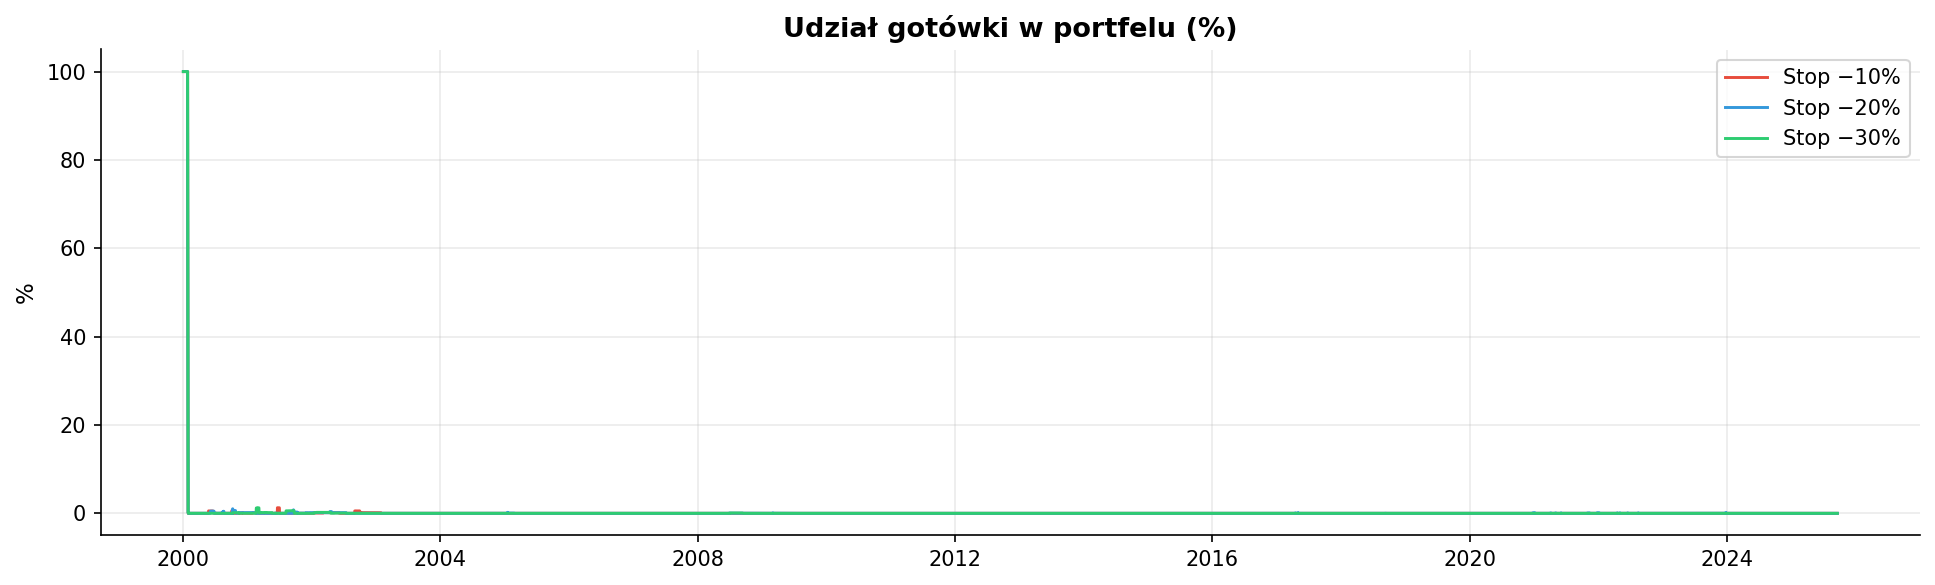

Saved: h06_udzial_gotowki.png


In [11]:
# ── Fig 6: Cash allocation in portfolio ────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
for (name, res), col in zip(results.items(), COLORS_LIST):
    cash_pct = res['cap']['cash'] / res['cap']['capital'] * 100
    ax.plot(res['cap'].index, cash_pct, label=name, color=col, linewidth=1.4)
ax.set_title('Udział gotówki w portfelu (%)', fontweight='bold')
ax.set_ylabel('%')
ax.legend()
plt.tight_layout()
fig.savefig(OUT / 'h06_udzial_gotowki.png', bbox_inches='tight')
plt.show()
print('Saved: h06_udzial_gotowki.png')


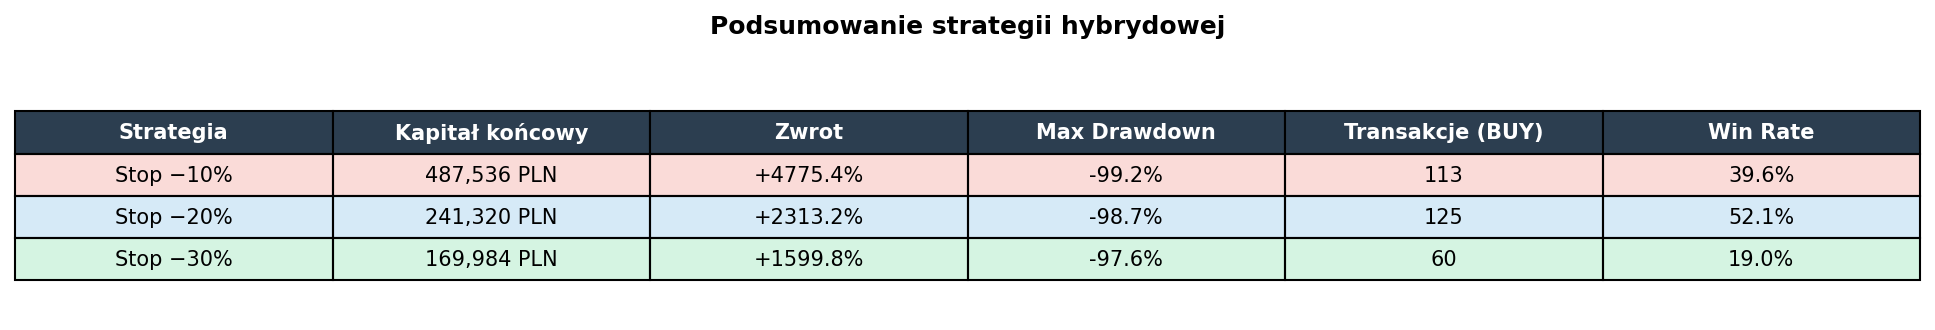

Saved: h07_tabela.png


In [12]:
# ── Fig 7: Summary table ───────────────────────────────────────────────
rows = []
for name, res in results.items():
    cap   = res['cap']['capital']
    final = cap.iloc[-1]
    ret   = (final / 10_000 - 1) * 100
    dd    = ((cap - cap.cummax()) / cap.cummax() * 100).min()
    td    = res['trades']
    ntxn  = len(td[td['action']=='BUY']) if not td.empty else 0
    # win rate na transakcjach parowanych
    if not td.empty:
        b = td[td['action']=='BUY'][['date','ticker','value']].reset_index(drop=True)
        s = td[td['action']=='SELL'][['date','ticker','value']].reset_index(drop=True)
        paired = pd.merge(b, s, on='ticker', suffixes=('_buy','_sell'))
        wr = (paired['value_sell'] > paired['value_buy']).mean() * 100 if len(paired) else 0
    else:
        wr = 0
    rows.append([name, f'{final:,.0f} PLN', f'{ret:+.1f}%',
                 f'{dd:.1f}%', str(ntxn), f'{wr:.1f}%'])

cols = ['Strategia', 'Kapitał końcowy', 'Zwrot', 'Max Drawdown', 'Transakcje (BUY)', 'Win Rate']
fig, ax = plt.subplots(figsize=(13, 2.2))
ax.axis('off')
tbl = ax.table(cellText=rows, colLabels=cols, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.8)
for j in range(len(cols)):
    tbl[0,j].set_facecolor('#2C3E50')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
for i, col in enumerate(COLORS_LIST, 1):
    for j in range(len(cols)):
        tbl[i,j].set_facecolor(col + '33')
fig.suptitle('Podsumowanie strategii hybrydowej', fontweight='bold', y=0.98)
plt.tight_layout()
fig.savefig(OUT / 'h07_tabela.png', bbox_inches='tight')
plt.show()
print('Saved: h07_tabela.png')


## 6. Animation

In [13]:
caps_m = {name: res['cap']['capital'].resample('M').last().dropna()
          for name, res in results.items()}
dates_m = list(caps_m.values())[0].index

fig, ax = plt.subplots(figsize=(12, 6))
all_vals = pd.concat(list(caps_m.values()))
ax.set_xlim(dates_m[0], dates_m[-1])
ax.set_ylim(all_vals.min() * 0.9, all_vals.max() * 1.1)
ax.axhline(10_000, color='gray', linestyle='--', alpha=0.4)
ax.set_title('Strategia hybrydowa GPW — symulacja 2000–2025',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Data'); ax.set_ylabel('Kapitał (PLN)')

lines  = [ax.plot([], [], color=c, linewidth=2, label=n)[0]
          for n, c in zip(caps_m, COLORS_LIST)]
dots   = [ax.plot([], [], 'o', color=c, markersize=6)[0] for c in COLORS_LIST]
labels = [ax.text(0, 0, '', color=c, fontsize=9, fontweight='bold')
          for c in COLORS_LIST]
date_txt = ax.text(0.02, 0.95, '', transform=ax.transAxes,
                   fontsize=11, color='#555', va='top')
ax.legend(loc='upper left', fontsize=9)

cap_arrays = [v.values for v in caps_m.values()]
frames = range(1, len(dates_m), 2)

def animate(i):
    for line, dot, lbl, arr in zip(lines, dots, labels, cap_arrays):
        line.set_data(dates_m[:i], arr[:i])
        dot.set_data([dates_m[i-1]], [arr[i-1]])
        lbl.set_position((dates_m[i-1], arr[i-1]*1.02))
        lbl.set_text(f'{arr[i-1]:,.0f}')
    date_txt.set_text(dates_m[i-1].strftime('%b %Y'))
    return lines + dots + labels + [date_txt]

anim = animation.FuncAnimation(fig, animate, frames=frames, interval=80, blit=True)
anim.save(OUT / 'animacja_hybrid.mp4', writer='ffmpeg', fps=15,
          extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p'])
print('Saved: animacja_hybrid.mp4')
anim.save(OUT / 'animacja_hybrid.gif', writer='pillow', fps=12)
print('Saved: animacja_hybrid.gif')
plt.close()


Saved: animacja_hybrid.mp4


Saved: animacja_hybrid.gif


## 7. Export Results to CSV

In [14]:
for name, res in results.items():
    slug = name.replace(' ', '_').replace('−','minus').replace('%','').lower()
    res['cap'].to_csv(OUT / f'{slug}_kapital.csv')
    if not res['trades'].empty:
        res['trades'].to_csv(OUT / f'{slug}_trades.csv', index=False)
    print(f'Saved: {slug}_*')

import os
print('\n--- charts_hybrid/ ---')
for f in sorted(os.listdir(OUT)): print(' ', f)


Saved: stop_minus10_*
Saved: stop_minus20_*
Saved: stop_minus30_*

--- charts_hybrid/ ---
  animacja_hybrid.gif
  animacja_hybrid.mp4
  h01_kapital_porownanie.png
  h02_drawdown.png
  h03_liczba_pozycji.png
  h04_zwrot_roczny.png
  h05_rozklad_zwrotow.png
  h06_udzial_gotowki.png
  h07_tabela.png
  stop_minus10_kapital.csv
  stop_minus10_trades.csv
  stop_minus20_kapital.csv
  stop_minus20_trades.csv
  stop_minus30_kapital.csv
  stop_minus30_trades.csv
